In [2]:
%cd ..

/scratch/big/home/daawic/BSc-Thesis


In [3]:
import os
import torch
import matplotlib.pyplot as plt
from torchvision.transforms import transforms
from project.models import EDMMauMau, EDMSerie
from project.agents import DQNAgent, DiffusionAgent
from project.util.transforms import Difference
from project.util.data import ReplayMemoryData
from project.util.metrics import PSNR, MSE

In [4]:
PATH = os.path.join("..", "checkpoints", "diff", "Breakout30.pt")
DATA = os.path.join("..", "checkpoints", "memory", "Breakout.pt")
DQN = os.path.join("..", "dqn", "Breakout.pt")
N = 8
SIGMA_NOISE_START = 0.1
SIGMA_NOISE_END = 1
NOISE_LEVELS = 5
SAMPLES = 100
N_ACTIONS = 4

In [5]:
device = "cuda:9"

In [6]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

In [7]:
data = ReplayMemoryData(
    memory=DATA,
    transform=transform,
    cap=500_000,
    train=False,
)

In [1]:
model_full = EDMSerie.from_checkpoint(PATH, device, sigma_noise=SIGMA_NOISE_START, N=N).to(device)
model_naive = EDMMauMau.from_checkpoint(PATH, device, sigma_noise=SIGMA_NOISE_START).to(device)

NameError: name 'EDMSerie' is not defined

In [ ]:
agent_base = DQNAgent(
    train=False,
    n_actions=N_ACTIONS
).load(DQN).to(device)
agent_naive = DiffusionAgent(
    model=model_naive,
    train=False,
    n_actions=N_ACTIONS
).load(DQN).to(device)
agent_full = DiffusionAgent(
    model=model_full,
    train=False,
    n_actions=N_ACTIONS
).load(DQN).to(device)

In [ ]:
q_values_base = torch.zeros((NOISE_LEVELS, SAMPLES))
q_values_base_clean = torch.zeros_like(q_values_base)
q_values_naive = torch.zeros_like(q_values_base)
q_values_full = torch.zeros_like(q_values_base)

x = torch.zeros((SAMPLES, 4, 84, 84), device=device)

for i, img in enumerate(torch.randperm(500_000)[:SAMPLES]):
    x[i] = data[img].to(device)

sigmas = torch.linspace(SIGMA_NOISE_START, SIGMA_NOISE_END, NOISE_LEVELS)

for i, sigma in enumerate(sigmas):

    model_full.set_sigma_noise(sigma)
    model_naive.set_sigma_noise(sigma)

    e = sigma * torch.randn_like(x)
    x_noisy = x + e

    with torch.no_grad():

        for j in range(SAMPLES):

            q_values_base_clean[i, j] = agent_base.q_values(x[j]).max()
            q_values_base[i, j] = agent_base.q_values(x_noisy[j]).max()
            q_values_naive[i, j] = agent_naive.q_values(x_noisy[j]).max()
            q_values_full[i, j] = agent_full.q_values(x_noisy[j]).max()

100%|██████████| 8/8 [00:09<00:00,  1.19s/it]


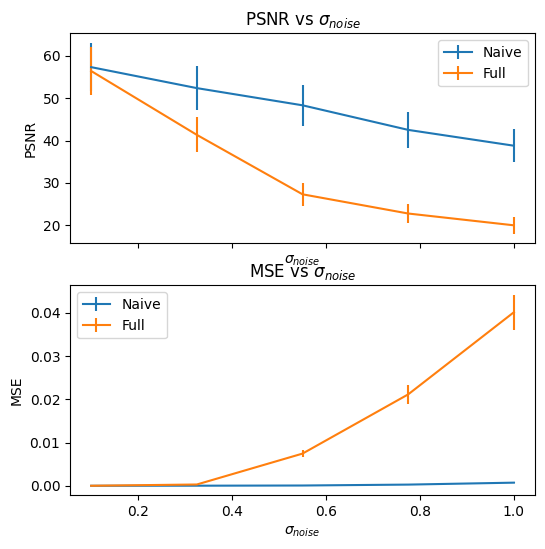

In [ ]:
plt.plot(sigmas, q_values_base_clean, label="Base (clean)")
plt.plot(sigmas, q_values_base, label="Base")
plt.plot(sigmas, q_values_naive, label="Naive")
plt.plot(sigmas, q_values_full, label="Full")

plt.set_xlabel("$\\sigma_{noise}$")
plt.set_ylabel("Q")
plt.set_title("Q-values vs $\\sigma_{noise}$")

plt.legend()

plt.show()